## Spectrum Investigation

Looking at the eigenspectrum of the diffusion maps diffusion operator and seeing if/how it relates to the embeddings we get in the first couple dimensions/how it impacts likelihood estimates.

In [15]:
import numpy as np 
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.io import loadmat
from scipy.sparse.linalg import eigsh
from matplotlib.colors import ListedColormap, BoundaryNorm


reload(dap)

np.set_printoptions(suppress=True)


In [16]:
def vstack_with_padding(a, b, pad_value=-999):
    # Find max length
    max_len = max(len(a), len(b))
    
    # Pad each array to the same length
    a_padded = np.pad(a, (0, max_len - len(a)), constant_values=pad_value)
    b_padded = np.pad(b, (0, max_len - len(b)), constant_values=pad_value)
    
    # Stack vertically
    return np.vstack([a_padded, b_padded])

In [17]:
uoep = {'mu': 0, 'sigma': 1}
poep = {'mu': 0, 'sigma': 1} 

uoep_sd = {'mu1': 2.0, 'sigma1': 1, 'mu2': -2.0, 'sigma2':1.0, 'threshold': 0}
poep_sd = {'mu1': 2.0, 'sigma1': 1, 'mu2': -2.0, 'sigma2':1.0, 'threshold': 0}


fice_uoep = {'mu': 0, 'sigma': 0.3, 'lnmu': 0, 'lnsigma': 1, 'lnscale': 30 } 
fice_t_params = {
    'a': 10, 'shift': 0.0, 'h_noise':0.0, 'v_noise':0.0, 'Nx':40, 'bound':3}
fice_e_params = {
    'a': 10, 'shift': 0.0,'h_noise':0.0, 'v_noise':0.0, 'Nx':40, 'bound': 3}
lfice_t_params = {
    'v_noise':0.0, 'Nx':40, 'f':1/2}
lfice_e_params = {
    'v_noise':0.0, 'Nx':40, 'f':1/2}



DB: starting cycle 0
DB: starting cycle 100
DB: starting cycle 200
DB: starting cycle 300
DB: starting cycle 400
DB: starting cycle 0
DB: starting cycle 100
DB: starting cycle 200
DB: starting cycle 300
DB: starting cycle 400


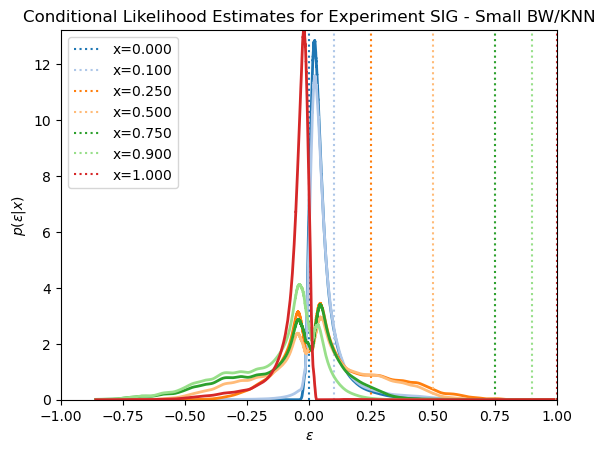

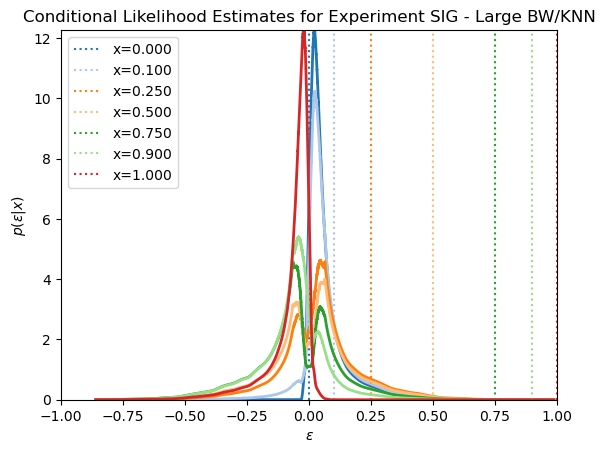

<Figure size 640x480 with 0 Axes>

In [24]:
expts = ['L96 - Gaussian', 'L96 - SD Gaussian', 'SIG - Small BW/KNN', 'SIG - Large BW/KNN']
bws = [0.05, 0.05, 0.01, 0.1]
knns = [0.2, 0.2, 0.2, 0.2]
m_flags = [1, 1, 5,5]
uoes =[0,1,2,2]
uoeps =[uoep, uoep_sd, fice_uoep, fice_uoep]
enum = [1,2,3,4]

expt_spectra = {}

klb=0.0
for e_name, bw, knn, m_flag,uoe, uoepa, num in zip(expts, bws, knns, m_flags, uoes, uoeps, enum):
    if num < 3:
        pass
    else:
        e = dap.Expt(e_name, {'expt_flag': 3,
                               'model_flag':m_flag,
                               'localize':1,
                               'obf': 2,
                               'seed': 58,
                               'qc_flag': 0,
                               'used_obs_err': uoe,
                               'prescribed_obs_err': 0,
                               'used_obs_err_params': uoepa,
                               'prescribed_obs_err_params': poep,
                               'save_keest_pab':1,
                               'Ne':40,
                               'T': 401,
                               'T_train': 400,
                               'Neig': 50,
                               'knn_frac': knn,
                               'bw_dm': bw,
                               'klb':klb,
                               'debug_nle_noDA': False})
        dap.runDA(e)
        fig, ax = plt.subplots()
        if m_flag == 5:
            dap.plot_pab(e, ax=ax, plot_states=True, pab_sample_states=[0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
        else:
            dap.plot_pab(e, ax=ax, plot_states=True, pab_sample_states=-999)
        expt_spectra[e_name] = vstack_with_padding(e.eigval_x, e.eigval_y)


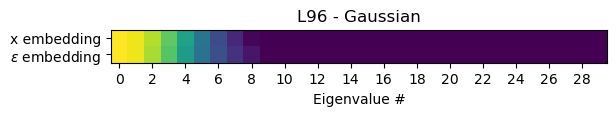

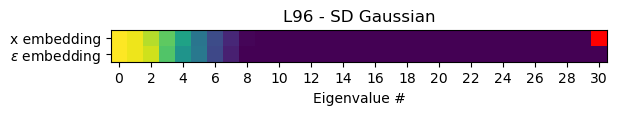

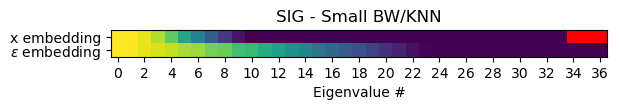

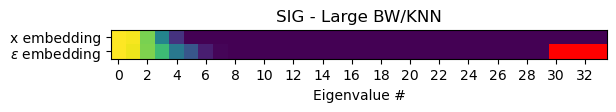

In [23]:
for key in expt_spectra:

    eigvals = expt_spectra[key]
    masked_arr = np.ma.masked_where(eigvals == -999, eigvals)
    
    # Choose a colormap and set a special color for masked values
    cmap = plt.cm.viridis.copy()   # copy so we don’t overwrite global cmap
    cmap.set_bad(color="red")      # masked values appear red
    
    # Plot
    im = plt.imshow(masked_arr, cmap=cmap, vmin=0.2, vmax=1, interpolation="none")
    
    # Colorbar (only real values show up)
    #plt.colorbar(im, label="Eigenvalue", orientation='horizontal')
    
    # Custom y-axis labels
    plt.title(key)
    plt.yticks([0, 1], ["x embedding", "$\\epsilon$ embedding"])
    plt.xticks(np.arange(0,eigvals.shape[1],2))
    plt.xlabel("Eigenvalue #")
    plt.show()
